In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [115]:
unharmonized_features=pd.read_csv(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\unharmonized_power_gamma40_data.csv")
zscore_features=pd.read_csv(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\unharmonized_zscore_power_gamma40_data.csv")
norm_demographics_features = pd.read_csv(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\neurocombat_power_gamma40_data.csv")


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

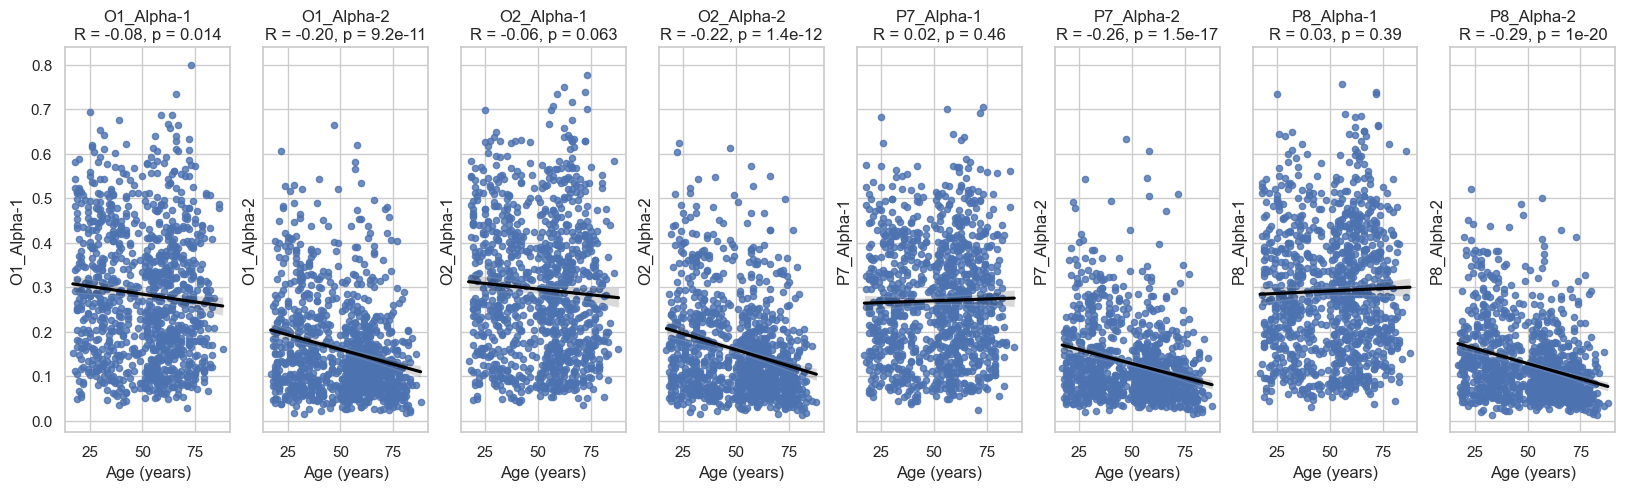

In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

results = []
feature_names_parietal_occipital = ['O1_Alpha-1', 'O1_Alpha-2', 'O2_Alpha-1',
                'O2_Alpha-2','P7_Alpha-1', 'P7_Alpha-2', 'P8_Alpha-1',
                'P8_Alpha-2']
for var in feature_names_parietal_occipital:
    corr, p_val = spearmanr(unharmonized_features['age'], unharmonized_features[var])
    results.append({'Variable': var, 'R': corr, 'p-value': p_val})

results_df = pd.DataFrame(results)

# Configurar el estilo
sns.set(style="whitegrid")

# Crear subplots
fig, axes = plt.subplots(1, len(feature_names_parietal_occipital), figsize=(20, 5), sharey=True)

for i, var in enumerate(feature_names_parietal_occipital):
    ax = axes[i]
    sns.regplot(
        x='age', y=var, data=unharmonized_features, 
        scatter_kws={'s': 20}, line_kws={'color': 'black'}, ax=ax
    )
    corr, p_val = spearmanr(unharmonized_features['age'], unharmonized_features[var])
    ax.set_title(f'{var}\nR = {corr:.2f}, p = {p_val:.2g}')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel(f'{var}')

plt.tight_layout

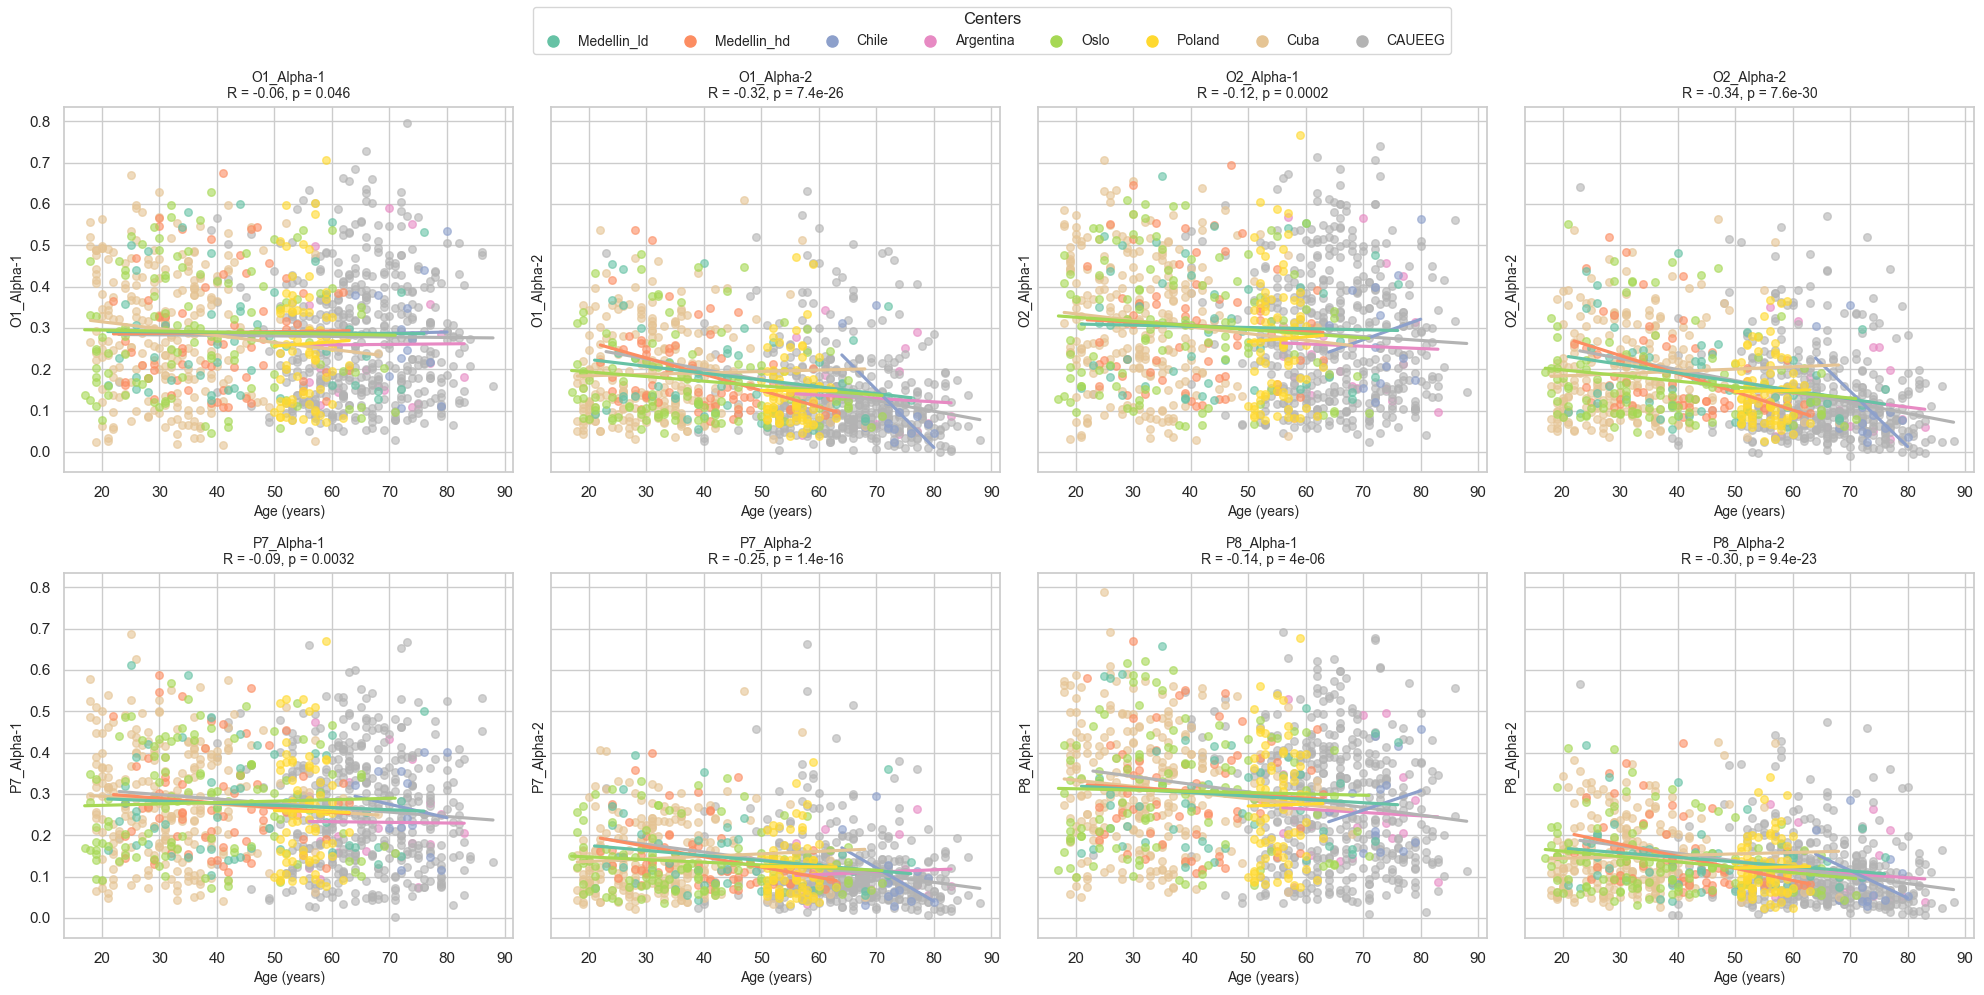

In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# Variables a analizar
feature_names_parietal_occipital = ['O1_Alpha-1', 'O1_Alpha-2', 'O2_Alpha-1',
                                    'O2_Alpha-2', 'P7_Alpha-1', 'P7_Alpha-2', 
                                    'P8_Alpha-1', 'P8_Alpha-2']
centers=list(norm_demographics_features.center.unique())
# Configurar estilo de gráficos
sns.set(style="whitegrid")

# Crear paleta de colores para los centros
palette = sns.color_palette("Set2", n_colors=len(centers))
color_map = dict(zip(centers, palette))

# Crear subplots
fig, axes = plt.subplots(2, len(feature_names_parietal_occipital) // 2, figsize=(20, 10), sharey=True)
axes = axes.flatten()

# Iterar sobre las características y graficar
for i, var in enumerate(feature_names_parietal_occipital):
    ax = axes[i]
    for center, group in norm_demographics_features.groupby('center'):
        sns.regplot(
            x='age', y=var, data=group,
            scatter_kws={'s': 30, 'alpha': 0.6, 'color': color_map[center]},  # Puntos por centro
            line_kws={'color': color_map[center]},  # Línea por centro
            ci=None, ax=ax
        )
    
    # Calcular y mostrar la correlación de Spearman
    corr, p_val = spearmanr(norm_demographics_features['age'], norm_demographics_features[var])
    ax.set_title(f'{var}\nR = {corr:.2f}, p = {p_val:.2g}', fontsize=10)
    ax.set_xlabel('Age (years)', fontsize=10)
    ax.set_ylabel(f'{var}', fontsize=10)

# Añadir leyenda global
handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=8, label=center) 
           for center, color in color_map.items()]
fig.legend(handles=handles, loc='upper center', ncol=len(centers), title='Centers', fontsize=10)

# Ajustar diseño
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Dejar espacio para la leyenda
plt.show()


In [8]:
!pip install pingouin

   ---------------------------------------- 0.0/204.4 kB ? eta -:--:--
   -------- ------------------------------- 41.0/204.4 kB 1.9 MB/s eta 0:00:01
   -------- ------------------------------- 41.0/204.4 kB 1.9 MB/s eta 0:00:01
   ------------------------ --------------- 122.9/204.4 kB 1.0 MB/s eta 0:00:01
   -------------------------------------- - 194.6/204.4 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 204.4/204.4 kB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   --------------------------- ------------ 204.8/294.9 kB 6.3 MB/s eta 0:00:01
   ------------------------------- -------- 235.5/294.9 kB 3.6 MB/s eta 0:00:01
   ---------------------------------- ----- 256.0/294.9 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 3.3 MB/s eta 0:0

  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\Luisa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
feature_names_parietal_occipital = ['O1_Alpha-1', 'O1_Alpha-2', 'O2_Alpha-1',
                'O2_Alpha-2','P7_Alpha-1', 'P7_Alpha-2', 'P8_Alpha-1',
                'P8_Alpha-2']

## Gaussian Process Regression

In [43]:
# perpare covariate_normsample for sex and age
import os 

processing_dir = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\gpr"    # replace with a path to your working directory
if not os.path.isdir(processing_dir):
    os.makedirs(processing_dir)
os.chdir(processing_dir)
processing_dir = os.getcwd()

covariate_normsample = norm_demographics_features[['age']]
print(covariate_normsample)
covariate_normsample.to_csv(processing_dir+'/covariate_normsample_eeg.txt',
                            sep = ' ',
                            header = False,
                            index = False)

print(feature_names_parietal_occipital)
features_normsample = norm_demographics_features[feature_names_parietal_occipital]
print(features_normsample)
features_normsample.to_csv(processing_dir+'/features_normsample_eeg.txt',
                           sep = ' ',
                           header = False,
                           index = False)


       age
0     42.0
1     31.0
2     59.0
3     68.0
4     59.0
...    ...
1023  67.0
1024  63.0
1025  66.0
1026  75.0
1027  80.0

[1028 rows x 1 columns]
['O1_Alpha-1', 'O1_Alpha-2', 'O2_Alpha-1', 'O2_Alpha-2', 'P7_Alpha-1', 'P7_Alpha-2', 'P8_Alpha-1', 'P8_Alpha-2']
      O1_Alpha-1  O1_Alpha-2  O2_Alpha-1  O2_Alpha-2  P7_Alpha-1  P7_Alpha-2  \
0       0.150122    0.093037    0.135512    0.087600    0.140341    0.085040   
1       0.306273    0.135567    0.351748    0.127001    0.227914    0.116517   
2       0.382829    0.051772    0.397921    0.059485    0.395165    0.067040   
3       0.147926    0.073852    0.145273    0.076061    0.170741    0.054638   
4       0.242906    0.159665    0.152675    0.107585    0.232383    0.133779   
...          ...         ...         ...         ...         ...         ...   
1023    0.213938    0.227481    0.194284    0.225070    0.237150    0.101654   
1024    0.335730    0.089453    0.317293    0.086411    0.356479    0.067490   
1025    0.

In [44]:
import pcntoolkit as pcn

# run normative modeling using 2-fold cross-validation

pcn.normative.estimate(covfile = processing_dir+'/covariate_normsample_eeg.txt',
                       respfile = processing_dir+'/features_normsample_eeg.txt',
                       cvfolds = 2,
                       alg = 'gpr',
                       outputsuffix = '_2fold')
                    # Load the estimated model


Processing data in D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\gpr/features_normsample_eeg.txt
Estimating model  1 of 8
Optimization terminated successfully.
         Current function value: -253.374626
         Iterations: 31
         Function evaluations: 73
         Gradient evaluations: 73
Estimating model  2 of 8
Optimization terminated successfully.
         Current function value: -430.137616
         Iterations: 24
         Function evaluations: 59
         Gradient evaluations: 59
Estimating model  3 of 8
Optimization terminated successfully.
         Current function value: -227.049234
         Iterations: 44
         Function evaluations: 95
         Gradient evaluations: 95
Estimating model  4 of 8


d:\flujo_portables\env\lib\site-packages\scipy\optimize\_optimize.py:1764: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


         Current function value: -433.645549
         Iterations: 33
         Function evaluations: 115
         Gradient evaluations: 104
Estimating model  5 of 8
Optimization terminated successfully.
         Current function value: -309.870986
         Iterations: 32
         Function evaluations: 75
         Gradient evaluations: 75
Estimating model  6 of 8
Optimization terminated successfully.
         Current function value: -559.014285
         Iterations: 19
         Function evaluations: 44
         Gradient evaluations: 44
Estimating model  7 of 8
Optimization terminated successfully.
         Current function value: -259.903867
         Iterations: 17
         Function evaluations: 45
         Gradient evaluations: 45
Estimating model  8 of 8


d:\flujo_portables\env\lib\site-packages\scipy\optimize\_optimize.py:1764: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


         Current function value: -557.470339
         Iterations: 28
         Function evaluations: 128
         Gradient evaluations: 116
Estimating model  1 of 8
Optimization terminated successfully.
         Current function value: -235.497284
         Iterations: 45
         Function evaluations: 109
         Gradient evaluations: 109
Estimating model  2 of 8
Optimization terminated successfully.
         Current function value: -434.291320
         Iterations: 21
         Function evaluations: 56
         Gradient evaluations: 56
Estimating model  3 of 8
Optimization terminated successfully.
         Current function value: -225.115889
         Iterations: 24
         Function evaluations: 59
         Gradient evaluations: 58
Estimating model  4 of 8


d:\flujo_portables\env\lib\site-packages\scipy\optimize\_optimize.py:1764: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


         Current function value: -425.595394
         Iterations: 23
         Function evaluations: 124
         Gradient evaluations: 104
Estimating model  5 of 8


d:\flujo_portables\env\lib\site-packages\scipy\optimize\_optimize.py:1764: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


         Current function value: -302.613002
         Iterations: 49
         Function evaluations: 165
         Gradient evaluations: 154
Estimating model  6 of 8
Optimization terminated successfully.
         Current function value: -573.850697
         Iterations: 36
         Function evaluations: 116
         Gradient evaluations: 107
Estimating model  7 of 8
Optimization terminated successfully.
         Current function value: -269.892193
         Iterations: 24
         Function evaluations: 95
         Gradient evaluations: 89
Estimating model  8 of 8
Optimization terminated successfully.
         Current function value: -562.897374
         Iterations: 32
         Function evaluations: 81
         Gradient evaluations: 81
Evaluating the model ...
Writing outputs ...


8
8
8


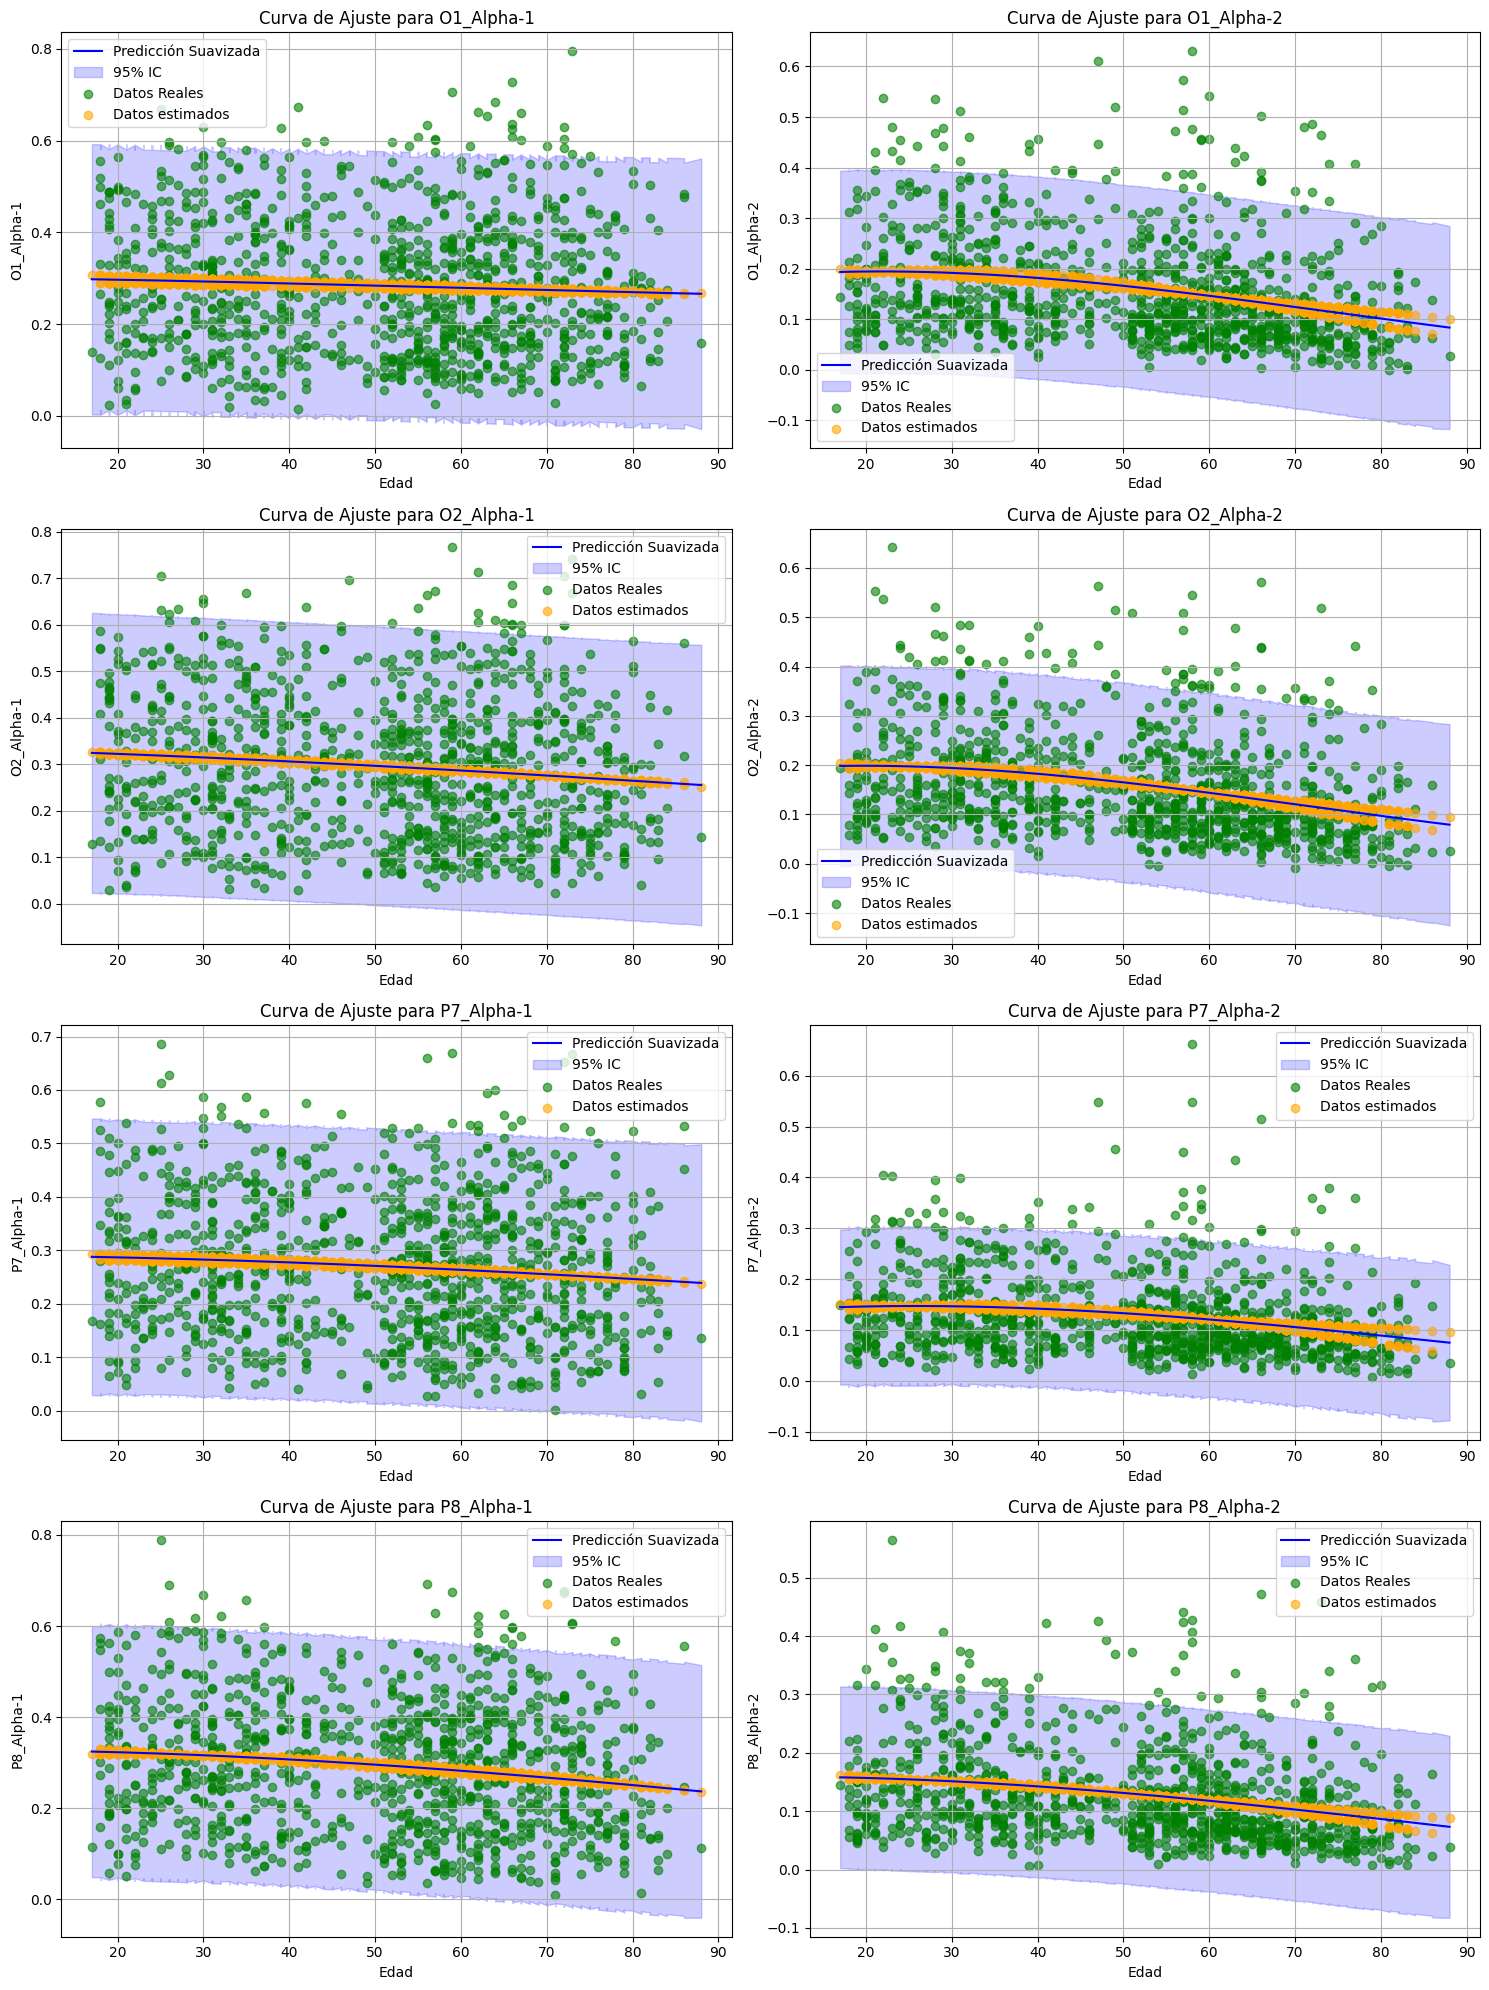

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_absolute_error, r2_score

# Constantes
z = 1.96  # Valor Z para un intervalo de confianza del 95%

# Cargar los datos
covariates = pd.read_csv(processing_dir+'/covariate_normsample_eeg.txt', sep=' ', header=None, names=['age'])
real_data = pd.read_csv(processing_dir+'/features_normsample_eeg.txt', sep=' ', header=None)
yhat = pd.read_csv(processing_dir+'/yhat_2fold.txt', sep=' ', header=None)
s2 = pd.read_csv(processing_dir+'/ys2_2fold.txt', sep=' ', header=None)

# Verificar tamaños de los DataFrames
print(len(feature_names_parietal_occipital)) 
print(len(feature_names_parietal_occipital))
print(len(feature_names_parietal_occipital))

# Extraer la edad y ordenar por edad
age = covariates['age']
sorted_indices = np.argsort(age)
age_sorted = age.iloc[sorted_indices]

# Crear subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

# Iterar sobre las características
for idx, feature in enumerate(feature_names_parietal_occipital):
    feature_index = idx  # Índice de la característica actual
    
    # Validar índices dentro del rango de columnas
    if feature_index >= real_data.shape[1] or feature_index >= yhat.shape[1] or feature_index >= s2.shape[1]:
        print(f"Índice {feature_index} fuera de rango para {feature}.")
        continue
    
    # Extraer datos de la característica
    yhat_feature = yhat.iloc[:, feature_index].values
    s2_feature = s2.iloc[:, feature_index].values
    real_data_feature = real_data.iloc[:, feature_index].values
    
    # Ordenar por edad
    yhat_sorted = yhat_feature[sorted_indices]
    s2_sorted = s2_feature[sorted_indices]
    real_data_sorted = real_data_feature[sorted_indices]
    # Aplicar suavizado con spline
    spline = UnivariateSpline(age_sorted, yhat_sorted, s=1)
    yhat_smooth = spline(age_sorted)
    
    # Calcular MAE y R²
    mae = mean_absolute_error(real_data_sorted, yhat_smooth)
    r2 = r2_score(real_data_sorted, yhat_smooth)
    
    # Graficar
    ax = axes[idx]
    ax.plot(age_sorted, yhat_smooth, label='Predicción Suavizada', color='blue')
    ax.fill_between(age_sorted, yhat_smooth - z * np.sqrt(s2_sorted), 
                    yhat_smooth + z * np.sqrt(s2_sorted), color='blue', alpha=0.2, label='95% IC')
    ax.scatter(age_sorted, real_data_sorted, color='green', label='Datos Reales', alpha=0.6)
    ax.scatter(age_sorted, yhat_sorted, color='orange', label='Datos estimados', alpha=0.6)
    
    # Personalizar el gráfico
    ax.set_xlabel('Edad')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature}\nMAE: {mae:.2f}, R²: {r2:.2f}')

    ax.legend()
    ax.grid(True)

# Ajustar diseño
plt.tight_layout()
plt.show()


BIC

EXPV (Explained Variance)

MSLL (Mean Standardized Log Loss)

NLL (Negative Log Likelihood)

Rho e correlación o escala del proceso de GPR

RMSE (Root Mean Squared Error)

SMSE (Standardized Mean Squared Error)

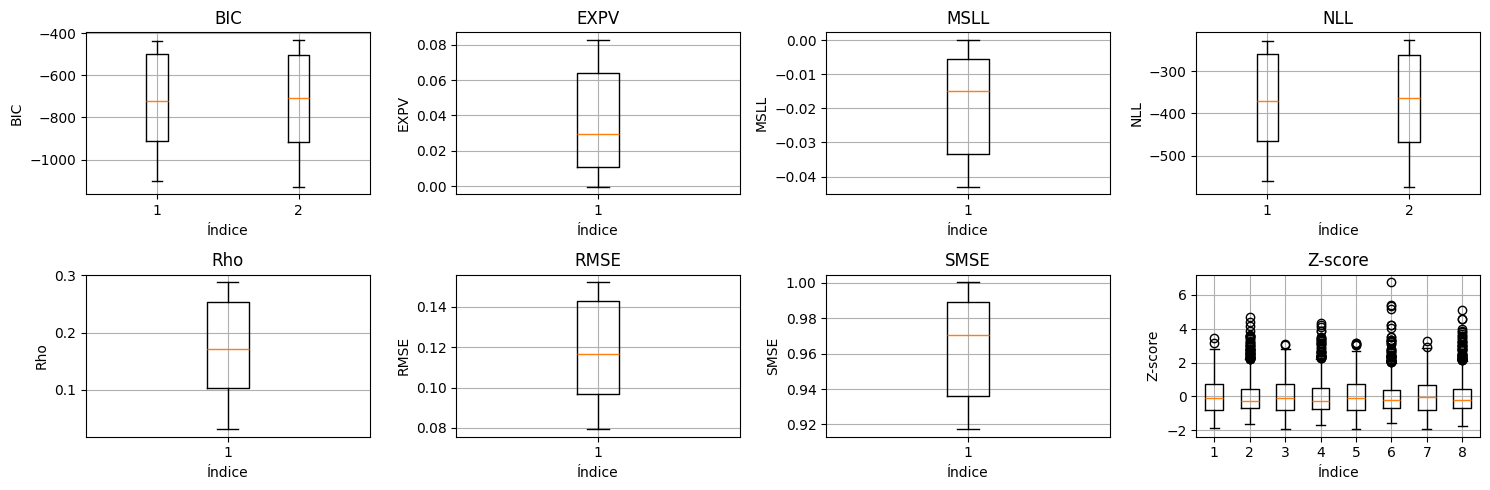

Promedio de RMSE: 0.1169


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Archivos de métricas
metricas_archivos = {
    'BIC': processing_dir+r'/BIC_2fold.txt',
    'EXPV': processing_dir+r'/EXPV_2fold.txt',
    'MSLL': processing_dir+r'/MSLL_2fold.txt',
    'NLL': processing_dir+r'/NLL_2fold.txt',
    'Rho': processing_dir+r'/Rho_2fold.txt',
    'RMSE': processing_dir+r'/RMSE_2fold.txt',
    'SMSE': processing_dir+r'/SMSE_2fold.txt',
    'Z-score': processing_dir+r'/Z_2fold.txt'
}

# Crear una figura con subplots
n_metricas = len(metricas_archivos)
n_filas = (n_metricas + 1) // 4 # Dos columnas
fig, axes = plt.subplots(nrows=n_filas, ncols=4, figsize=( 15,5))
axes = axes.flatten()  # Convertir en una lista para indexar

# Leer y graficar cada métrica
for i, (nombre_metrica, archivo) in enumerate(metricas_archivos.items()):
    try:
        # Leer los datos
        datos = pd.read_csv(archivo, sep=' ', header=None)
        
        # Graficar en el subplot correspondiente
        axes[i].boxplot(datos)
        axes[i].set_title(f'{nombre_metrica}')
        axes[i].set_xlabel('Índice')
        axes[i].set_ylabel(nombre_metrica)
        axes[i].grid(True)
    except FileNotFoundError:
        axes[i].set_title(f'{nombre_metrica} no encontrado')
        axes[i].axis('off')  # Desactivar el gráfico si falta el archivo

# Ocultar subplots vacíos si hay menos métricas que subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Ajustar diseño
plt.tight_layout()
plt.savefig('metricas_grafico_unico.png')
plt.show()

# Calcular y mostrar el promedio de RMSE
try:
    rmse_data = pd.read_csv(r'./RMSE_2fold.txt', sep=' ', header=None)
    rmse_promedio = rmse_data.mean()[0]
    print(f'Promedio de RMSE: {rmse_promedio:.4f}')
except FileNotFoundError:
    print('Archivo RMSE no encontrado para calcular el promedio.')


## Hierarchical Bayesian Regression

In [2]:
import os
import pandas as pd
import pcntoolkit as ptk
import numpy as np
import pickle
from matplotlib import pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
processing_dir = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\HBR"    # replace with a path to your working directory
if not os.path.isdir(processing_dir):
    os.makedirs(processing_dir)
os.chdir(processing_dir)
processing_dir = os.getcwd()

In [96]:
norm_demographics_features.center.unique()

array(['Medellin_ld', 'Medellin_hd', 'Chile', 'Argentina', 'Oslo',
       'Poland', 'Cuba', 'CAUEEG'], dtype=object)

['Medellin_ld' 'Medellin_hd' 'Chile' 'Argentina' 'Poland' 'Cuba' 'CAUEEG']
site Medellin_ld 50
site Medellin_hd 65
site Chile 13
site Argentina 19
site Poland 77
site Cuba 247
site CAUEEG 446


C:\Users\Luisa\AppData\Local\Temp\ipykernel_17088\4264273262.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oslo['sitenum'] = 0
C:\Users\Luisa\AppData\Local\Temp\ipykernel_17088\4264273262.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_demographics_features['sitenum'].loc[idx] = i
C:\Users\Luisa\AppData\Local\Temp\ipykernel_17088\4264273262.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

Text(0.5, 0, 'age')

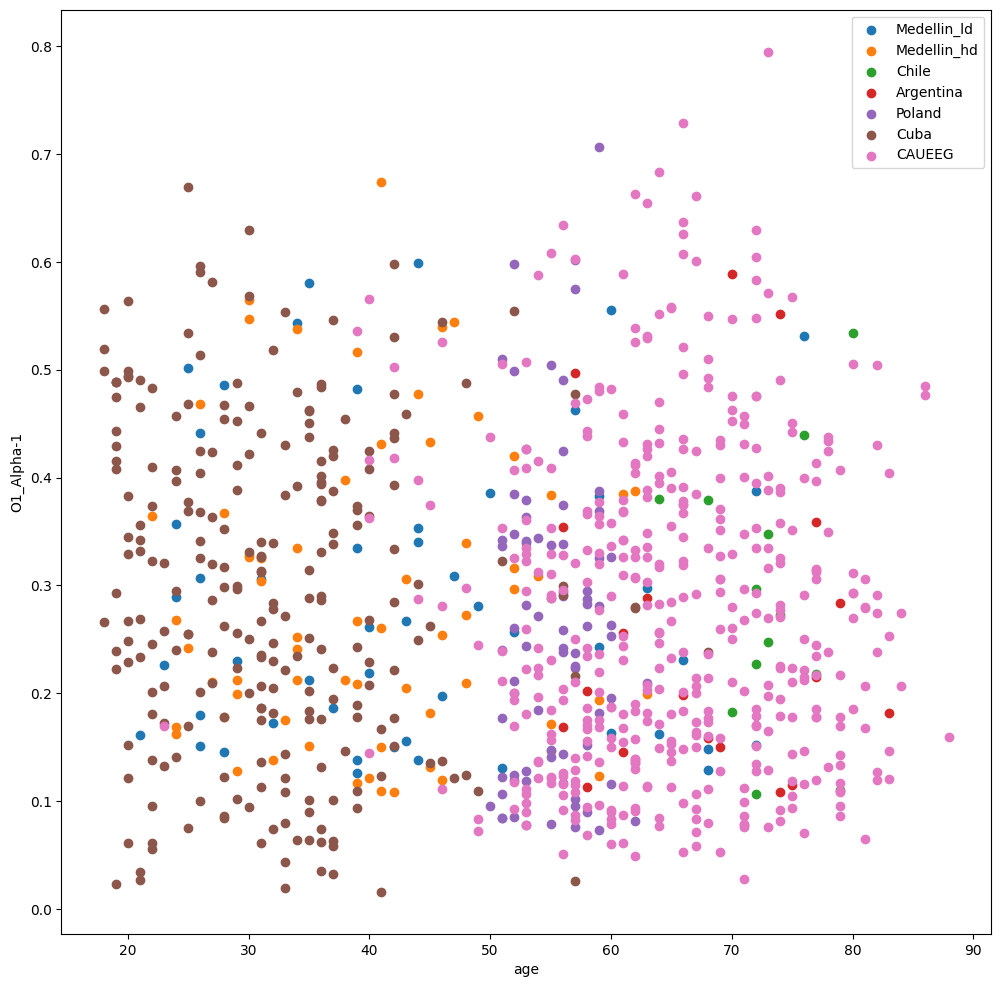

In [97]:
oslo = norm_demographics_features.loc[norm_demographics_features['center'] == 'Oslo']
oslo['sitenum'] = 0
norm_demographics_features = norm_demographics_features.loc[norm_demographics_features['center'] != 'Oslo']
norm_demographics_features['sitenum'] = 0
sites = norm_demographics_features['center'].unique()
print(sites)

f, ax = plt.subplots(figsize=(12, 12))

for i,s in enumerate(sites):
    idx = norm_demographics_features['center'] == s
    norm_demographics_features['sitenum'].loc[idx] = i

    print('site',s, sum(idx))
    ax.scatter(norm_demographics_features['age'].loc[idx], norm_demographics_features['O1_Alpha-1'].loc[idx])

ax.legend(sites)
ax.set_ylabel('O1_Alpha-1')
ax.set_xlabel('age')


In [99]:
norm_demographics_features.drop(['C3_Alpha-1', 'C3_Alpha-2', 'C3_Beta1', 'C3_Beta2', 'C3_Beta3',
       'C3_Delta', 'C3_Gamma', 'C3_Theta', 'C4_Alpha-1', 'C4_Alpha-2',
       'C4_Beta1', 'C4_Beta2', 'C4_Beta3', 'C4_Delta', 'C4_Gamma', 'C4_Theta',
       'FP1_Alpha-1', 'FP1_Alpha-2', 'FP1_Beta1', 'FP1_Beta2', 'FP1_Beta3',
       'FP1_Delta', 'FP1_Gamma', 'FP1_Theta', 'FP2_Alpha-1', 'FP2_Alpha-2',
       'FP2_Beta1', 'FP2_Beta2', 'FP2_Beta3', 'FP2_Delta', 'FP2_Gamma',
       'FP2_Theta', 'O1_Beta1', 'O1_Beta2', 'O1_Beta3', 'O1_Delta', 'O1_Gamma', 'O1_Theta',
       'O2_Beta1', 'O2_Beta2', 'O2_Beta3', 'O2_Delta','O2_Gamma', 'O2_Theta', 'P7_Alpha-1', 'P7_Alpha-2', 'P7_Beta1',
       'P7_Beta2', 'P7_Beta3', 'P7_Delta', 'P7_Gamma', 'P7_Theta',
       'P8_Alpha-1', 'P8_Alpha-2', 'P8_Beta1', 'P8_Beta2', 'P8_Beta3',
       'P8_Delta', 'P8_Gamma', 'P8_Theta'], inplace=True, axis=1)

In [100]:
tr = np.random.uniform(size=norm_demographics_features.shape[0]) > 0.5
te = ~tr

norm_demographics_features_tr = norm_demographics_features.loc[tr]
norm_demographics_features_te = norm_demographics_features.loc[te]

tr = np.random.uniform(size=oslo.shape[0]) > 0.5
te = ~tr

oslo_tr = oslo.loc[tr]
oslo_te = oslo.loc[te]

print('sample size check')
for i,s in enumerate(sites):
    idx = norm_demographics_features_tr['center'] == s
    idxte = norm_demographics_features_te['center'] == s
    print(i,s, sum(idx), sum(idxte))

norm_demographics_features_tr.to_csv(processing_dir + '/norm_demographics_features1000_tr.csv')
norm_demographics_features_te.to_csv(processing_dir + '/norm_demographics_features1000_te.csv')
oslo_tr.to_csv(processing_dir + '/norm_demographics_features1000_oslo_tr.csv')
oslo_te.to_csv(processing_dir + '/norm_demographics_features1000_oslo_te.csv')
print(oslo_tr)

sample size check
0 Medellin_ld 28 22
1 Medellin_hd 38 27
2 Chile 7 6
3 Argentina 10 9
4 Poland 40 37
5 Cuba 118 129
6 CAUEEG 221 225
     C3_Alpha-1  C3_Alpha-2  C3_Beta1  C3_Beta2  C3_Beta3  C3_Delta  C3_Gamma  \
152    0.212365    0.060821  0.084374  0.024219  0.081861  0.337382  0.030101   
154    0.122683    0.099135  0.139329  0.070483  0.106319  0.286600  0.085932   
155    0.117049    0.105547  0.100004  0.020508  0.053543  0.479643  0.026623   
157    0.167817    0.098801  0.176245  0.040695  0.054675  0.279695  0.025364   
158    0.154632    0.132146  0.193717  0.032124  0.062811  0.319932  0.031410   
159    0.285045    0.059111  0.145602  0.023632  0.033520  0.172183  0.020437   
162    0.337352    0.056701  0.016995  0.009723  0.018595  0.217996  0.008131   
163    0.170138    0.114860  0.180304  0.040671  0.068775  0.298278  0.027086   
167    0.385292    0.089873  0.141631  0.051380  0.046173  0.170648  0.018427   
171    0.167587    0.141232  0.146809  0.030890  0.06520

In [75]:
idps =  ['O2_Alpha-1','O2_Alpha-2']

#### Step 2: Configure HBR inputs: covariates, measures and batch effects

In [76]:
X_train = (norm_demographics_features_tr['age']/100).to_numpy(dtype=float)
Y_train = norm_demographics_features_tr[idps].to_numpy(dtype=float)
batch_effects_train = norm_demographics_features_tr[['sitenum']].to_numpy(dtype=int)

with open('X_train.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_train), file)
with open('Y_train.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_train), file)
with open('trbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_train), file)


X_test = (norm_demographics_features_te['age']/100).to_numpy(dtype=float)
Y_test = norm_demographics_features_te[idps].to_numpy(dtype=float)
batch_effects_test = norm_demographics_features_te[['sitenum']].to_numpy(dtype=int)

with open('X_test.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_test), file)
with open('Y_test.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_test), file)
with open('tsbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_test), file)

# a simple function to quickly load pickle files
def ldpkl(filename: str):
    with open(filename, 'rb') as f:
        return pickle.load(f)

#### Step 3: Files and Folders grooming

In [77]:
respfile = os.path.join(processing_dir, 'Y_train.pkl')       # measurements  (eg cortical thickness) of the training samples (columns: the various features/ROIs, rows: observations or subjects)
covfile = os.path.join(processing_dir, 'X_train.pkl')        # covariates (eg age) the training samples (columns: covariates, rows: observations or subjects)

testrespfile_path = os.path.join(processing_dir, 'Y_test.pkl')       # measurements  for the testing samples
testcovfile_path = os.path.join(processing_dir, 'X_test.pkl')        # covariate file for the testing samples

trbefile = os.path.join(processing_dir, 'trbefile.pkl')      # training batch effects file (eg scanner_id, gender)  (columns: the various batch effects, rows: observations or subjects)
tsbefile = os.path.join(processing_dir, 'tsbefile.pkl')      # testing batch effects file

output_path = os.path.join(processing_dir, 'Models/')    #  output path, where the models will be written
log_dir = os.path.join(processing_dir, 'log/')           #
if not os.path.isdir(output_path):
    os.mkdir(output_path)
if not os.path.isdir(log_dir):
    os.mkdir(log_dir)

outputsuffix = '_estimate'

#### Step 4: Estimating the models

In [78]:
ptk.normative.estimate(covfile=covfile,
                       respfile=respfile,
                       tsbefile=tsbefile,
                       trbefile=trbefile,
                       alg='hbr',
                       log_path=log_dir,
                       binary=True,
                       output_path=output_path, 
                       testcov= testcovfile_path,
                       testresp = testrespfile_path,
                       outputsuffix=outputsuffix, savemodel=True)



Processing data in D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\HBR\Y_train.pkl
Estimating model  1 of 2


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 5075 seconds.
There were 30 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Sampling: [y_like]


Normal


...

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 5666 seconds.
There were 40 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Sampling: [y_like]


Normal


Saving model meta-data...
Evaluating the model ...
Writing outputs ...


### Step 5: Transfering the models to unseen sites

In [101]:
idps

['O2_Alpha-1', 'O2_Alpha-2']

In [108]:
X_adapt = (oslo_tr['age']/100).to_numpy(dtype=float)
Y_adapt = oslo_tr[idps].to_numpy(dtype=float)
batch_effects_adapt = oslo_tr[['sitenum']].to_numpy(dtype=int)

with open('X_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_adapt), file)
with open('Y_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_adapt), file)
with open('adbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_adapt), file)

# Test data (new dataset)
X_test_txfr = (oslo_te['age']/100).to_numpy(dtype=float)
Y_test_txfr = oslo_te[idps].to_numpy(dtype=float)
batch_effects_test_txfr = oslo_te[['sitenum']].to_numpy(dtype=int)

with open('X_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_test_txfr), file)
with open('Y_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_test_txfr), file)
with open('txbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_test_txfr), file)

In [80]:
ptk.normative.estimate(covfile=covfile,
                       respfile=respfile,
                       tsbefile=tsbefile,
                       trbefile=trbefile,
                       alg='hbr',
                       log_path=log_dir,
                       binary=True,
                       output_path=output_path, testcov= testcovfile_path,
                       testresp = testrespfile_path,
                       outputsuffix=outputsuffix, savemodel=True)

Processing data in D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\HBR\Y_train.pkl
Estimating model  1 of 2


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 4952 seconds.
There were 22 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Sampling: [y_like]


Normal


...

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 5177 seconds.
There were 21 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Sampling: [y_like]


Normal


Saving model meta-data...
Evaluating the model ...
Writing outputs ...


In [112]:
X_adapt = (oslo_tr['age']/100).to_numpy(dtype=float)
Y_adapt = oslo_tr[idps].to_numpy(dtype=float)
batch_effects_adapt = oslo_tr[['sitenum']].to_numpy(dtype=int)

with open('X_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_adapt), file)
with open('Y_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_adapt), file)
with open('adbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_adapt), file)

# Test data (new dataset)
X_test_txfr = (oslo_te['age']/100).to_numpy(dtype=float)
Y_test_txfr = oslo_te[idps].to_numpy(dtype=float)
batch_effects_test_txfr = oslo_te[['sitenum']].to_numpy(dtype=int)

with open('X_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_test_txfr), file)
with open('Y_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_test_txfr), file)
with open('txbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_test_txfr), file)

In [113]:
respfile = os.path.join(processing_dir, 'Y_adaptation.pkl')
covfile = os.path.join(processing_dir, 'X_adaptation.pkl')
testrespfile_path = os.path.join(processing_dir, 'Y_test_txfr.pkl')
testcovfile_path = os.path.join(processing_dir, 'X_test_txfr.pkl')
trbefile = os.path.join(processing_dir, 'adbefile.pkl')
tsbefile = os.path.join(processing_dir, 'txbefile.pkl')

log_dir = os.path.join(processing_dir, 'log_transfer/')
output_path = os.path.join(processing_dir, 'Transfer/')
model_path = os.path.join(processing_dir, 'Models/')  # path to the previously trained models
outputsuffix = '_transfer'  # suffix added to the output files from the transfer function

In [114]:
yhat, s2, z_scores = ptk.normative.transfer(covfile=covfile,
                                            respfile=respfile,
                                            tsbefile=tsbefile,
                                            trbefile=trbefile,
                                            model_path = model_path,
                                            alg='hbr',
                                            log_path=log_dir,
                                            binary=True,
                                            output_path=output_path,
                                            testcov= testcovfile_path,
                                            testresp = testrespfile_path,
                                            outputsuffix=outputsuffix,
                                            savemodel=True)

Loading data ...
Using HBR transform...
Transferring model  1 of 2


d:\flujo_portables\env\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
d:\flujo_portables\env\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 1178 seconds.
There were 118 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Using HBR transform...
Transferring model  2 of 2


d:\flujo_portables\env\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
d:\flujo_portables\env\lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1030: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 822 seconds.
There were 154 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Evaluating the model ...
Writing outputs ...
